In [1]:
try:
    %load_ext autotime
except:
    !pip install ipython-autotime
    %load_ext autotime

try:
    %load_ext pulp
except:
    !pip3 install pulp
    

The pulp module is not an IPython extension.
time: 281 ms (started: 2024-10-25 19:29:18 -07:00)


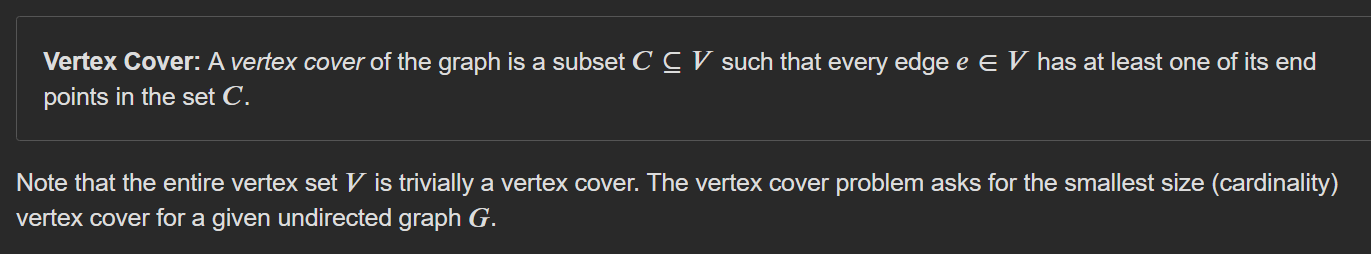

Practical application of vertex cover

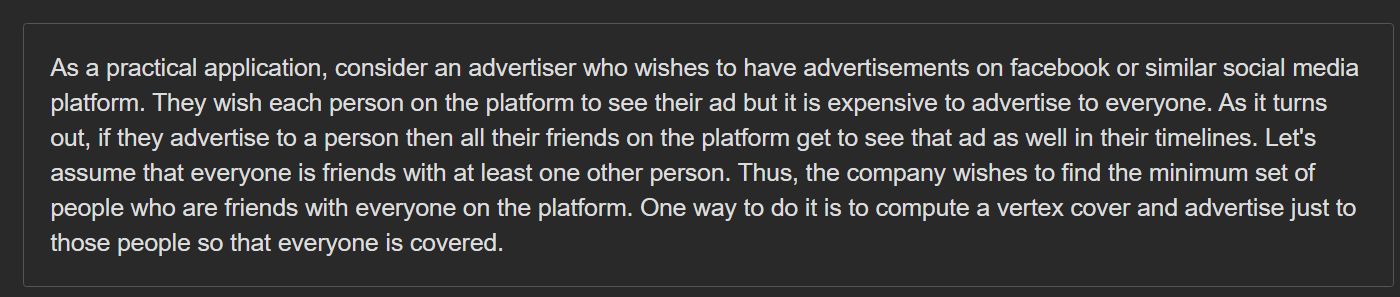

We have seen previously that the problem is NP-complete and can be solved in many ways including a reduction to integer linear programming. Here, we consider fast algorithms for computing an approximate vertex cover and our natural choice is to consider greedy algorithms.

Consider the example below where we show a graph with five nodes and the nodes in the vertex cover shaded in orange. In fact, the set  {1,4,5} is a vertex cover but there is in fact a smaller vertex cover consisting just the nodes  {4,5} . Note - code following plots the same graph

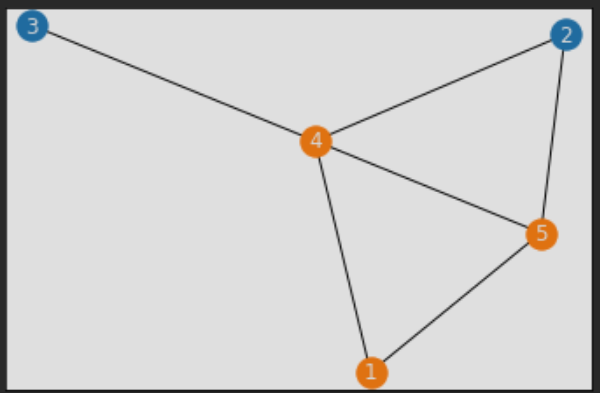



In [2]:
import networkx as nx
from matplotlib import pyplot as plt
from pylab import rcParams

# Use matplotlib and networkx to plot graphs with a designated
# vertex cover passed in as a list of vertices.
# n: number of vertices
# edge_list: list of edges. please ensure that if edge (i,j) 
#            is present then (j,i) is not. We will not be checking this.
# vert_cover: list of vertices in the cover to highlight in orange.
# All nodes will be plotted in blue with vertex cover highlighted in orange.
def plot_graph_with_vc(n, edge_list, vert_cover):
    g = nx.Graph()
    g.add_edges_from(edge_list)
    pos = nx.spring_layout(g)  # positions for all nodes
    not_vert_cover = [i for i in range(1, n+1) if i not in vert_cover]
    plt.figure(1)
    nx.draw_networkx_nodes(g, pos, nodelist=vert_cover,  node_color="tab:orange")
    nx.draw_networkx_nodes(g, pos, nodelist=not_vert_cover,  node_color="tab:blue")
    nx.draw_networkx_edges(g, pos, edgelist=edge_list)
    nx.draw_networkx_labels(g, pos, font_size=12, font_color="whitesmoke")
    plt.show()
    

time: 7.53 s (started: 2024-10-25 20:11:28 -07:00)


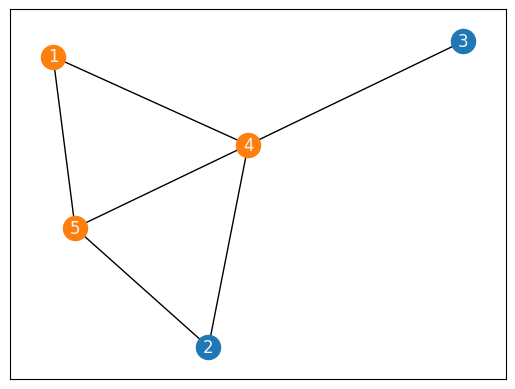

time: 421 ms (started: 2024-10-25 20:11:47 -07:00)


In [3]:
edge_list=[ (1,4), (1,5), (2,5), (2,4), (3,4), (4,5)]
vert_cover = [1,  4, 5]
plot_graph_with_vc(5, edge_list, vert_cover)

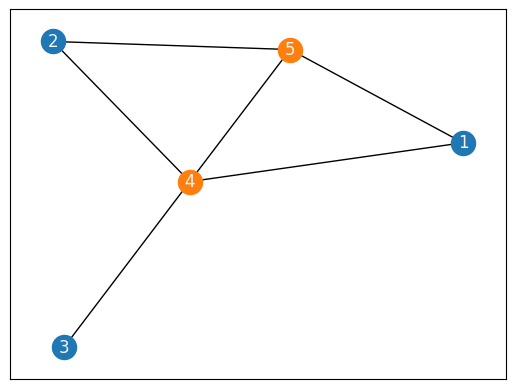

time: 94 ms (started: 2024-10-25 20:13:02 -07:00)


In [4]:
edge_list=[ (1,4), (1,5), (2,5), (2,4), (3,4), (4,5)]
smaller_vert_cover = [4, 5]
plot_graph_with_vc(5, edge_list, smaller_vert_cover)

<h2>Integer Linear Programming Formulation for Vertex Cover</h2>
We will present an integer linear programming formulation of the vertex cover problem. Let  𝐺 
  be a graph with vertices  𝑉={1,…,𝑛}   and undirected edges  𝐸. The edges  (𝑖,𝑗)  and  (𝑗,𝑖)
  are taken to be the same.

We will assume familiarity with the PuLP solver from previous lesson on linear programming.

<h3>Decision Variables></h3>
We will have  𝑛 decision variables  𝑤1,…,𝑤𝑛  that will be binary variables: they will have values in  {0,1}.  𝑤𝑖=1   indicates that the vertex  𝑖   is chosen as part of the cover and  𝑤𝑖=0   tells us that it is not.
To declare a variable as binary in pulp, we simply use the following approach:

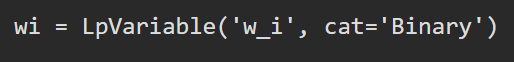

<h3>Objective Function</h3>
With the decision variables fixed as above, the objective is simply 
minimize 𝑤1+⋯+𝑤𝑛

We are minimizing the total over the binary variables which simply gives us the size of the cover.

<h3>Constraints</h3>

The key constraints are that (a)  𝑤1,…,𝑤𝑛   are binary (already mentioned above) and (b) for every edge  (𝑖,𝑗)
  at least one of  𝑖,𝑗 must be in the cover. In other words, at least one of  𝑤𝑖,𝑤𝑗   must be  1. The inequalities take care of this requirement:

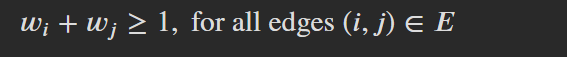

<h2>Putting it all together </h2>
<h3>(note - minimization is given by mistake as maximization in picture following)</h3>

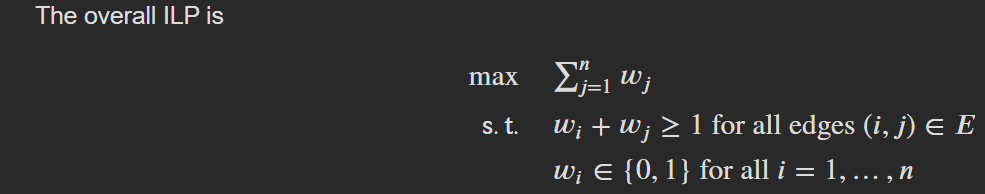







In [5]:
from pulp import *

def compute_optimal_vertex_cover(n, edge_list):
    # Create a problem -- indicate that we will minimize the objectives
    prob = LpProblem('vert_cover', LpMinimize)
    # Add all the decision vars
    dvars = [LpVariable(f'w_{i}', cat='Binary') for i in range(1, n+1)]
    # Note that lpSum is defined in Pulp (same as using python sum)  and it simply takes the sum of all variables in a list of vars.
    prob += lpSum(dvars) # minimize the sum of the variables
    for (i, j) in edge_list: # go through each edge in the list
        assert 1 <= i <= n 
        assert 1 <= j <= n
        prob += dvars[i-1] + dvars[j-1] >= 1

    stat = prob.solve() # solve the problem
    assert stat == LpStatusOptimal, 'Problem does not have optimal status -- something went wrong -- this should not happen for this problem'
    vert_cover = [i+1 for i in range(n) if dvars[i].varValue > 0 ]
    return vert_cover

time: 0 ns (started: 2024-10-25 20:32:24 -07:00)


[4, 5]
Optimal vertex cover has 2 vertices: [4, 5]


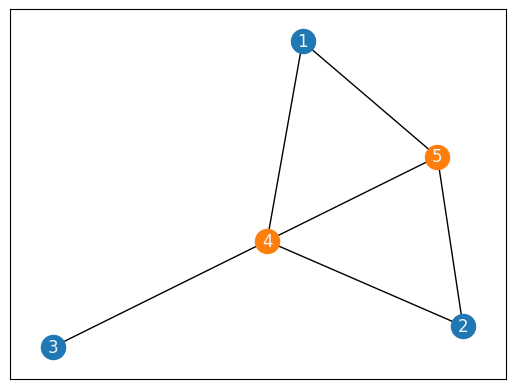

time: 313 ms (started: 2024-10-25 20:32:59 -07:00)


In [6]:
edge_list=[ (1,4), (1,5), (2,5), (2,4), (3,4), (4,5)]
opt_vcover = compute_optimal_vertex_cover(5, edge_list)
print(opt_vcover)
print(f'Optimal vertex cover has {len(opt_vcover)} vertices: {opt_vcover}')
plot_graph_with_vc(5, edge_list, opt_vcover)

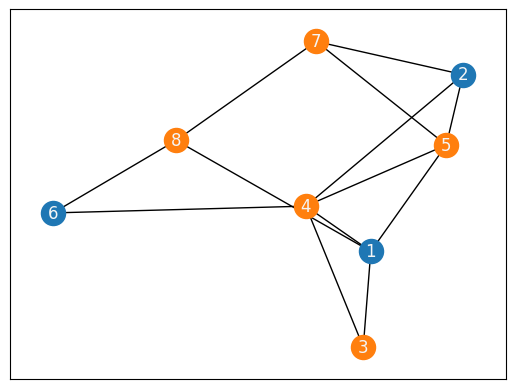

time: 125 ms (started: 2024-10-25 20:33:15 -07:00)


In [7]:
edge_list=[ (1,4), (1,5), (2,5), (2,4), (3,4), (4,5),(1,8),(2,7), (7,8),(4,6), (5,7), (6,8), (3,1)]
vcover = compute_optimal_vertex_cover(8, edge_list)
plot_graph_with_vc(8, edge_list, vcover)

Size of cover: 28 consisting of vertices [1, 2, 3, 5, 6, 10, 12, 14, 15, 17, 19, 21, 22, 23, 24, 25, 26, 27, 28, 30, 31, 32, 33, 34, 35, 37, 38, 39]


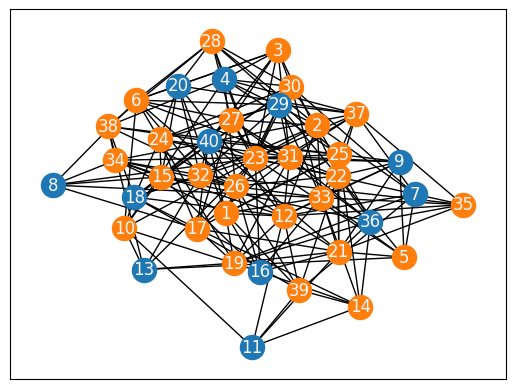

time: 219 ms (started: 2024-10-25 20:33:30 -07:00)


In [8]:
from random import randint
# graph with 40 vertices and 240 edges
n = 40
edge_list = [ ]
for _ in range(240):
    i = randint(1, n)
    j = randint(1, n)
    if i == 0 or j == 0 or i == j or (i,j) in edge_list or (j,i) in edge_list: 
        continue
    edge_list.append((i,j))

vcover = compute_optimal_vertex_cover(n, edge_list)
print(f'Size of cover: {len(vcover)} consisting of vertices {vcover}')
plot_graph_with_vc(n, edge_list, vcover)

In [14]:
from pulp import *

def compute_optimal_vertex_cover_quiz_question(n, edge_list):
    # Create a problem -- indicate that we will minimize the objectives
    prob = LpProblem('vert_cover', LpMinimize)
    # Add all the decision vars
    dvars = [LpVariable(f'w_{i}', cat='Binary') for i in range(1, n+1)]
    # Note that lpSum is defined in Pulp (same as using python sum)  and it simply takes the sum of all variables in a list of vars.
    prob += lpSum(dvars) # minimize the sum of the variables
    for (i, j) in edge_list: # go through each edge in the list
        assert 1 <= i <= n 
        assert 1 <= j <= n
        prob += dvars[i-1] + dvars[j-1] >= 1
        prob += dvars[i-1] + dvars[j-1] <= 1

    stat = prob.solve() # solve the problem
    # assert stat == LpStatusOptimal, 'Problem does not have optimal status -- something went wrong -- this should not happen for this problem'
    vert_cover = [i+1 for i in range(n) if dvars[i].varValue > 0 ]
    return vert_cover

time: 16 ms (started: 2024-10-25 20:48:59 -07:00)


In [15]:
edge_list=[ (1,4), (1,5), (2,5), (2,4), (3,4), (4,5)]
opt_vcover = compute_optimal_vertex_cover_quiz_question(5, edge_list)
print(opt_vcover)
# print(f'Optimal vertex cover has {len(opt_vcover)} vertices: {opt_vcover}')
# plot_graph_with_vc(5, edge_list, opt_vcover)

[1, 2, 3, 4, 5]
time: 31 ms (started: 2024-10-25 20:49:01 -07:00)


Size of cover: 40 consisting of vertices [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40]


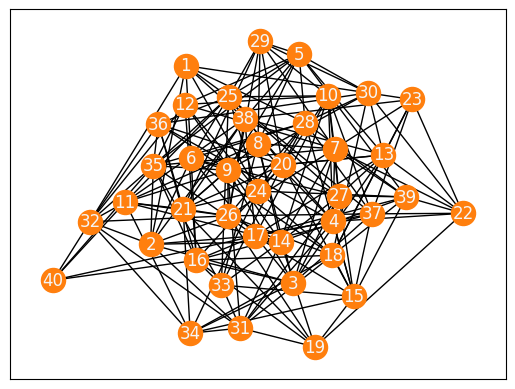

time: 219 ms (started: 2024-10-25 20:52:18 -07:00)


In [16]:
from random import randint
# graph with 40 vertices and 240 edges
n = 40
edge_list = [ ]
for _ in range(240):
    i = randint(1, n)
    j = randint(1, n)
    if i == 0 or j == 0 or i == j or (i,j) in edge_list or (j,i) in edge_list: 
        continue
    edge_list.append((i,j))

vcover = compute_optimal_vertex_cover_quiz_question(n, edge_list)
print(f'Size of cover: {len(vcover)} consisting of vertices {vcover}')
plot_graph_with_vc(n, edge_list, vcover)